In [1]:
import math
import random

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn.linear_model

In [3]:
mango_data = pd.read_csv("../dx601-homework-04/mango-tiny.tsv", sep="\t")

In [4]:
mango_data

,green_rating,yellow_rating,softness,wrinkles,estimated_flavor,estimated_sweetness,rated_flavor
0,1,5,4,0,4,4,5
1,1,5,5,1,5,5,1
2,2,4,3,1,3,3,3
3,3,3,2,0,2,1,2
4,5,1,1,1,1,1,1
5,4,2,1,1,1,1,1
6,5,1,1,1,2,1,1
7,3,3,2,1,2,2,2


In [5]:
mango_data.columns

Index(['green_rating', 'yellow_rating', 'softness', 'wrinkles',
       'estimated_flavor', 'estimated_sweetness', 'rated_flavor'],
      dtype='object')

## Linear Model Parameters:
For a linear model: ŷ = β₀ + β₁x₁ + β₂x₂ + ... + β₆x₆

6 coefficients (one for each feature: β₁, β₂, β₃, β₄, β₅, β₆)
1 intercept (β₀)

Total parameters = 6 + 1 = 7
Therefore: p1 = 7

In [6]:
features = mango_data.columns.drop("rated_flavor")
total_coefficients = len(features)
intercept = 1
p1 = total_coefficients + intercept
p1

7

In [7]:
import math

def f(x):
    """Original function: f(x) = x^3 - 3x"""
    return x**3 - 3*x

def f_prime(x):
    """First derivative: f'(x) = 3x^2 - 3"""
    return 3*x**2 - 3

def f_double_prime(x):
    """Second derivative: f''(x) = 6x"""
    return 6*x

def solve_quadratic(a, b, c):
    """
    Solve ax^2 + bx + c = 0 using quadratic formula
    Returns list of real solutions
    """
    discriminant = b**2 - 4*a*c
    
    if discriminant < 0:
        return []  # No real solutions
    elif discriminant == 0:
        return [-b / (2*a)]  # One solution
    else:
        sqrt_discriminant = math.sqrt(discriminant)
        x1 = (-b + sqrt_discriminant) / (2*a)
        x2 = (-b - sqrt_discriminant) / (2*a)
        return [x1, x2]

def find_critical_points():
    """
    Find critical points by solving f'(x) = 0 programmatically
    f'(x) = 3x^2 - 3 = 0
    This is a quadratic equation: 3x^2 + 0x + (-3) = 0
    """
    print("Solving f'(x) = 3x² - 3 = 0 programmatically:")
    
    # Coefficients for 3x^2 + 0x + (-3) = 0
    a = 3
    b = 0  
    c = -3
    
    print(f"Quadratic equation: {a}x² + {b}x + {c} = 0")
    
    # Solve using quadratic formula
    critical_points = solve_quadratic(a, b, c)
    
    print(f"Solutions: {critical_points}")
    
    # Verify each solution
    print("Verification:")
    for x in critical_points:
        f_prime_value = f_prime(x)
        print(f"  f'({x}) = {f_prime_value} ≈ 0? {abs(f_prime_value) < 1e-10}")
    
    return sorted(critical_points)

def count_local_extrema():
    """Count the number of local extrema using second derivative test"""
    critical_points = find_critical_points()
    extrema_count = 0
    
    print("Critical Points Analysis:")
    print("-" * 40)
    
    for x in critical_points:
        first_deriv = f_prime(x)
        second_deriv = f_double_prime(x)
        func_value = f(x)
        
        print(f"At x = {x}:")
        print(f"  f'({x}) = {first_deriv}")
        print(f"  f''({x}) = {second_deriv}")
        print(f"  f({x}) = {func_value}")
        
        # Second derivative test
        if abs(first_deriv) < 1e-10:  # f'(x) ≈ 0 (critical point)
            if second_deriv > 0:
                print(f"  → Local minimum")
                extrema_count += 1
            elif second_deriv < 0:
                print(f"  → Local maximum")
                extrema_count += 1
            else:
                print(f"  → Inconclusive (f''(x) = 0)")
        
        print()
    
    return extrema_count

def verify_with_numerical_check():
    """Verify by checking sign changes in f'(x)"""
    print("Numerical Verification:")
    print("-" * 40)
    
    # Check f'(x) values around critical points
    test_points = [-2, -1.5, -1, -0.5, 0, 0.5, 1, 1.5, 2]
    
    print("x\t|\tf'(x)\t|\tSign")
    print("-" * 30)
    
    signs = []
    for x in test_points:
        deriv_val = f_prime(x)
        sign = "+" if deriv_val > 0 else "-" if deriv_val < 0 else "0"
        signs.append(sign)
        print(f"{x}\t|\t{deriv_val:.2f}\t|\t{sign}")
    
    # Count sign changes
    sign_changes = 0
    for i in range(1, len(signs)):
        if signs[i-1] != signs[i] and signs[i-1] != "0" and signs[i] != "0":
            sign_changes += 1
    
    print(f"\nSign changes in f'(x): {sign_changes}")
    return sign_changes

# Main calculation
if __name__ == "__main__":
    print("Finding local extrema for f(x) = x³ - 3x")
    print("=" * 50)
    
    # Method 1: Second derivative test
    p6 = count_local_extrema()
    
    # Method 2: Numerical verification
    sign_changes = verify_with_numerical_check()
    
    print("=" * 50)
    print(f"RESULT: p6 = {p6}")
    print(f"The function f(x) = x³ - 3x has {p6} local extrema")
    
    # Additional info
    critical_points = find_critical_points()
    print(f"\nCritical points: {critical_points}")
    for x in critical_points:
        extrema_type = "maximum" if f_double_prime(x) < 0 else "minimum"
        print(f"  x = {x}: Local {extrema_type} at ({x}, {f(x)})")

Finding local extrema for f(x) = x³ - 3x
Solving f'(x) = 3x² - 3 = 0 programmatically:
Quadratic equation: 3x² + 0x + -3 = 0
Solutions: [1.0, -1.0]
Verification:
  f'(1.0) = 0.0 ≈ 0? True
  f'(-1.0) = 0.0 ≈ 0? True
Critical Points Analysis:
----------------------------------------
At x = -1.0:
  f'(-1.0) = 0.0
  f''(-1.0) = -6.0
  f(-1.0) = 2.0
  → Local maximum

At x = 1.0:
  f'(1.0) = 0.0
  f''(1.0) = 6.0
  f(1.0) = -2.0
  → Local minimum

Numerical Verification:
----------------------------------------
x	|	f'(x)	|	Sign
------------------------------
-2	|	9.00	|	+
-1.5	|	3.75	|	+
-1	|	0.00	|	0
-0.5	|	-2.25	|	-
0	|	-3.00	|	-
0.5	|	-2.25	|	-
1	|	0.00	|	0
1.5	|	3.75	|	+
2	|	9.00	|	+

Sign changes in f'(x): 0
RESULT: p6 = 2
The function f(x) = x³ - 3x has 2 local extrema
Solving f'(x) = 3x² - 3 = 0 programmatically:
Quadratic equation: 3x² + 0x + -3 = 0
Solutions: [1.0, -1.0]
Verification:
  f'(1.0) = 0.0 ≈ 0? True
  f'(-1.0) = 0.0 ≈ 0? True

Critical points: [-1.0, 1.0]
  x = -1.0: Loca

Convexity Check:
------------------------------
 1. x²           -> CONVEX
 2. -x²          -> NOT CONVEX
 3. x³           -> NOT CONVEX
 4. x⁴           -> CONVEX
 5. x²-9x        -> CONVEX
 6. x            -> CONVEX
 7. 1000x²-x⁴    -> CONVEX
 8. 1/x          -> CONVEX
 9. -x           -> CONVEX
10. 0.001x²      -> CONVEX
------------------------------
Total convex functions (p7): 8


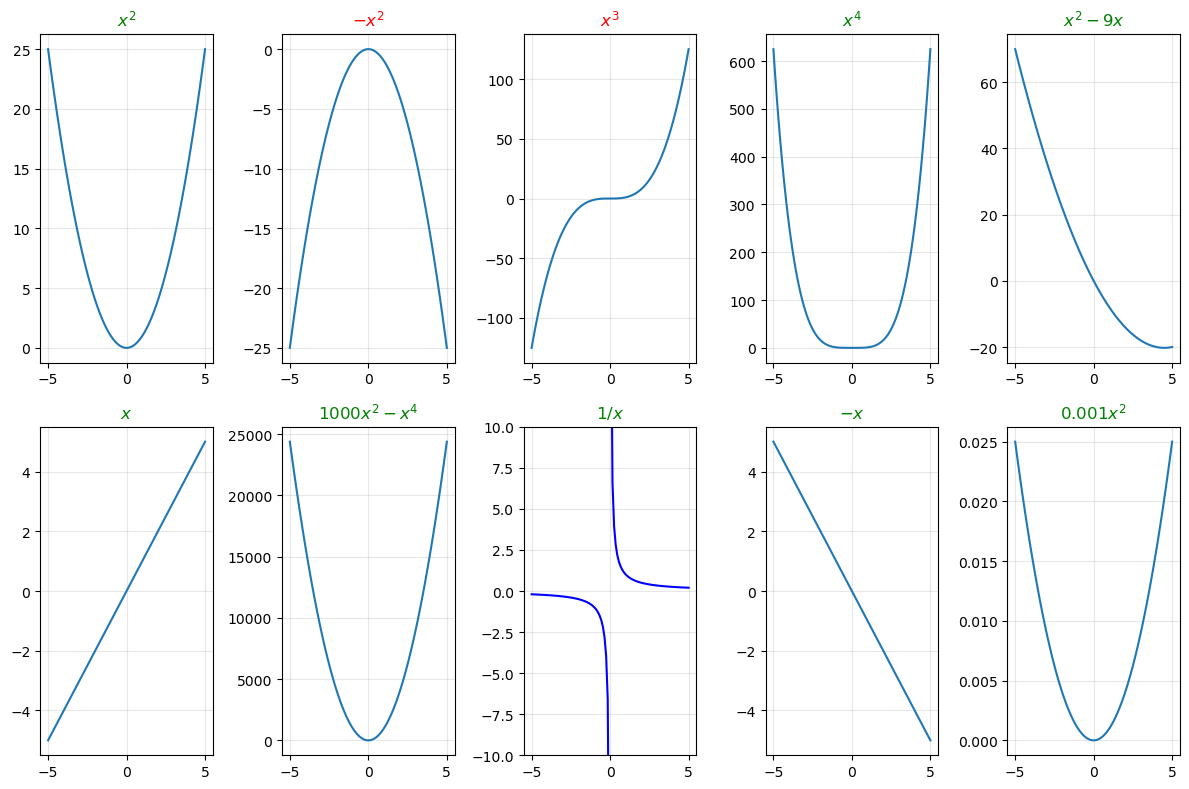


Convex functions are:
  1. x²
  4. x⁴
  5. x²-9x
  6. x
  7. 1000x²-x⁴
  8. 1/x
  9. -x
  10. 0.001x²


In [8]:
import numpy as np
import matplotlib.pyplot as plt

def is_convex_simple(func, x_min=-5, x_max=5, num_points=1000):
    """
    Simple convexity check using numerical second derivative
    Returns True if convex, False otherwise
    """
    x = np.linspace(x_min, x_max, num_points)
    
    try:
        y = func(x)
        
        # Calculate second derivative using finite differences
        dx = x[1] - x[0]
        # Second derivative ≈ (f(x+h) - 2f(x) + f(x-h)) / h²
        second_deriv = (y[2:] - 2*y[1:-1] + y[:-2]) / (dx**2)
        
        # Function is convex if second derivative >= 0 (allow small negative values due to numerical errors)
        return np.all(second_deriv >= -1e-10)
    
    except:
        return False

# Define all your functions
def f1(x): return x**2
def f2(x): return -x**2  
def f3(x): return x**3
def f4(x): return x**4
def f5(x): return x**2 - 9*x
def f6(x): return x
def f7(x): return 1000*x**2 - x**4
def f8(x): return np.where(x != 0, 1/x, np.inf)  # Handle division by zero
def f9(x): return -x
def f10(x): return 0.001 * x**2

# Test all functions
functions = [f1, f2, f3, f4, f5, f6, f7, f8, f9, f10]
names = ["x²", "-x²", "x³", "x⁴", "x²-9x", "x", "1000x²-x⁴", "1/x", "-x", "0.001x²"]

print("Convexity Check:")
print("-" * 30)

convex_count = 0
for i, (func, name) in enumerate(zip(functions, names)):
    if i == 7:  # Special case for 1/x, test on positive domain only
        result = is_convex_simple(func, x_min=0.1, x_max=5)
    else:
        result = is_convex_simple(func)
    
    status = "CONVEX" if result else "NOT CONVEX"
    print(f"{i+1:2}. {name:12} -> {status}")
    
    if result:
        convex_count += 1

print("-" * 30)
print(f"Total convex functions (p7): {convex_count}")

# Visual verification - recreate your plot with results
xs = np.linspace(-5, 5, 100)

plt.figure(figsize=(12, 8))
titles = ["$x^2$", "$-x^2$", "$x^3$", "$x^4$", "$x^2 - 9x$", 
          "$x$", "$1000x^2 - x^4$", "$1/x$", "$-x$", "$0.001 x^2$"]

for i in range(10):
    plt.subplot(2, 5, i+1)
    
    if i == 7:  # 1/x function
        xs_pos = xs[xs > 0]
        xs_neg = xs[xs < 0] 
        plt.plot(xs_pos, 1/xs_pos, 'b-')
        plt.plot(xs_neg, 1/xs_neg, 'b-')
        plt.ylim(-10, 10)
    else:
        plt.plot(xs, functions[i](xs))
    
    # Check convexity and color title accordingly
    if i == 7:
        convex = is_convex_simple(functions[i], x_min=0.1, x_max=5)
    else:
        convex = is_convex_simple(functions[i])
    
    color = 'green' if convex else 'red'
    plt.title(titles[i], color=color, fontweight='bold')
    plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# List the convex functions
print("\nConvex functions are:")
for i, (func, name) in enumerate(zip(functions, names)):
    if i == 7:
        result = is_convex_simple(func, x_min=0.1, x_max=5)
    else:
        result = is_convex_simple(func)
    if result:
        print(f"  {i+1}. {name}")

EXAMPLE 1: Testing f(x) = x²
We know this should be convex because f''(x) = 2 > 0

=== STEP-BY-STEP CONVEXITY CHECK ===
Step 1: Created 21 x values from -2 to 2
First few x values: [-2.  -1.8 -1.6 -1.4 -1.2]
Step size (dx): 0.200000

Step 2: Calculated y = f(x) for all x values
First few y values: [4.   3.24 2.56 1.96 1.44]

Step 3: Calculate second derivative using finite differences
Second derivative formula: f''(x) ≈ (f(x+h) - 2f(x) + f(x-h)) / h²
Where h = dx = 0.200000

Detailed calculation for first few points:
Point 1: x=-1.800
  f(x-h) = f(-2.000) = 4.000000
  f(x)   = f(-1.800) = 3.240000
  f(x+h) = f(-1.600) = 2.560000
  f''(x) = (2.560000 - 2×3.240000 + 4.000000) / 0.0400000000
  f''(x) = 2.000000

Point 2: x=-1.600
  f(x-h) = f(-1.800) = 3.240000
  f(x)   = f(-1.600) = 2.560000
  f(x+h) = f(-1.400) = 1.960000
  f''(x) = (1.960000 - 2×2.560000 + 3.240000) / 0.0400000000
  f''(x) = 2.000000

Point 3: x=-1.400
  f(x-h) = f(-1.600) = 2.560000
  f(x)   = f(-1.400) = 1.960000
  f

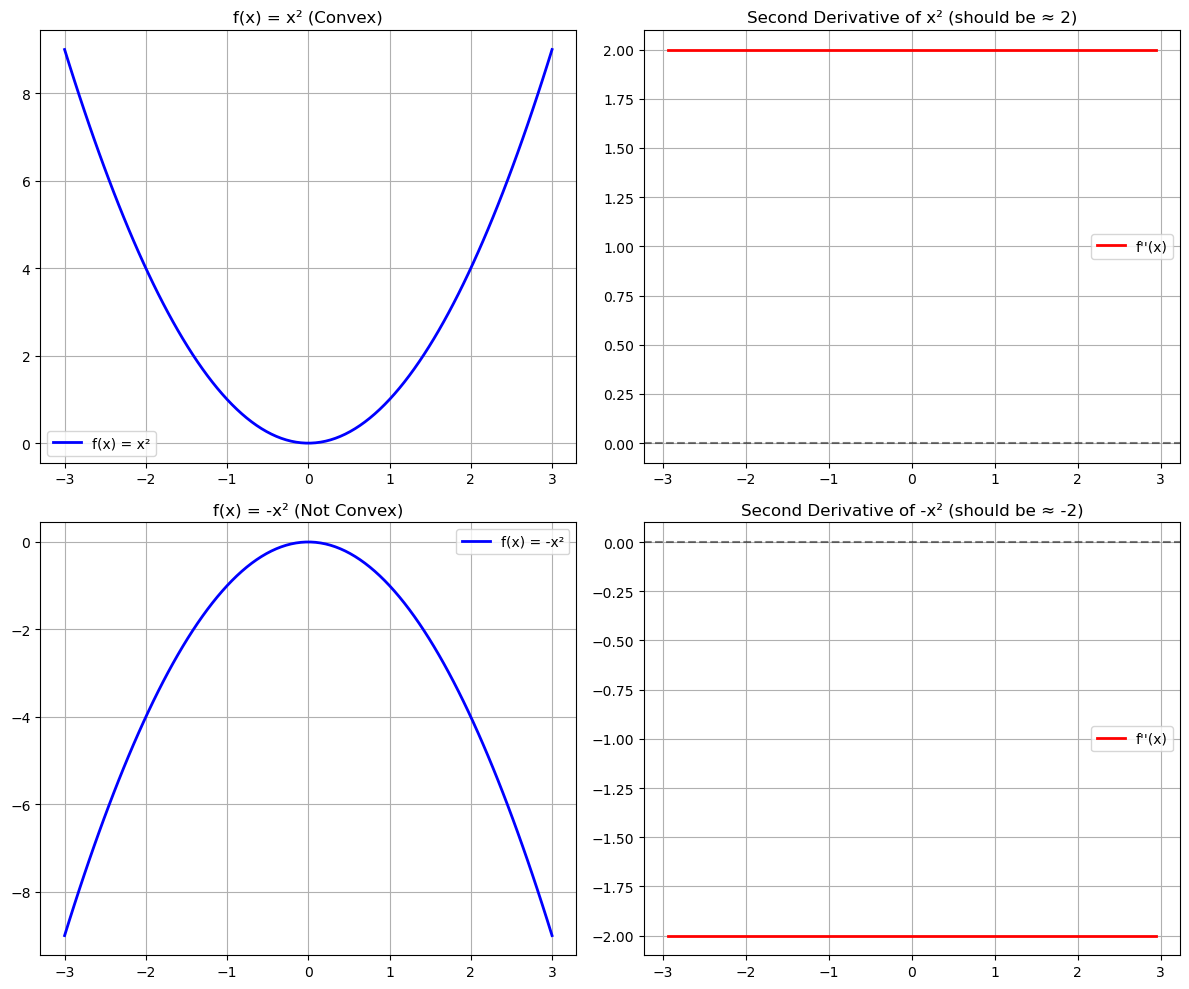


KEY INSIGHTS:
1. Second derivative tells us the 'curvature' of the function
2. Positive second derivative = curves upward = CONVEX
3. Negative second derivative = curves downward = NOT CONVEX
4. We use finite differences to approximate the second derivative numerically
5. The formula (f(x+h) - 2f(x) + f(x-h))/h² approximates f''(x)


In [9]:
import numpy as np
import matplotlib.pyplot as plt

def is_convex_simple_explained(func, x_min=-5, x_max=5, num_points=1000):
    """
    Detailed explanation of convexity checking with step-by-step breakdown
    """
    print(f"\n=== STEP-BY-STEP CONVEXITY CHECK ===")
    
    # STEP 1: Create x values
    x = np.linspace(x_min, x_max, num_points)
    print(f"Step 1: Created {num_points} x values from {x_min} to {x_max}")
    print(f"First few x values: {x[:5]}")
    print(f"Step size (dx): {x[1] - x[0]:.6f}")
    
    # STEP 2: Calculate function values
    try:
        y = func(x)
        print(f"\nStep 2: Calculated y = f(x) for all x values")
        print(f"First few y values: {y[:5]}")
    except:
        print("Error calculating function values!")
        return False
    
    # STEP 3: Calculate second derivative using finite differences
    dx = x[1] - x[0]  # Step size
    
    print(f"\nStep 3: Calculate second derivative using finite differences")
    print(f"Second derivative formula: f''(x) ≈ (f(x+h) - 2f(x) + f(x-h)) / h²")
    print(f"Where h = dx = {dx:.6f}")
    
    # Let's show the calculation for a few points manually
    print(f"\nDetailed calculation for first few points:")
    for i in range(1, min(4, len(y)-1)):
        f_plus = y[i+1]   # f(x+h)
        f_center = y[i]   # f(x)  
        f_minus = y[i-1]  # f(x-h)
        
        second_deriv_manual = (f_plus - 2*f_center + f_minus) / (dx**2)
        
        print(f"Point {i}: x={x[i]:.3f}")
        print(f"  f(x-h) = f({x[i-1]:.3f}) = {f_minus:.6f}")
        print(f"  f(x)   = f({x[i]:.3f}) = {f_center:.6f}")
        print(f"  f(x+h) = f({x[i+1]:.3f}) = {f_plus:.6f}")
        print(f"  f''(x) = ({f_plus:.6f} - 2×{f_center:.6f} + {f_minus:.6f}) / {dx**2:.10f}")
        print(f"  f''(x) = {second_deriv_manual:.6f}")
        print()
    
    # STEP 4: Calculate second derivative for all points
    # Note: We lose first and last points because we need neighbors
    second_deriv = (y[2:] - 2*y[1:-1] + y[:-2]) / (dx**2)
    
    print(f"Step 4: Calculated second derivative for all interior points")
    print(f"Original points: {len(y)}, Second derivative points: {len(second_deriv)}")
    print(f"First few second derivatives: {second_deriv[:5]}")
    print(f"Last few second derivatives: {second_deriv[-5:]}")
    
    # STEP 5: Check convexity condition
    min_second_deriv = np.min(second_deriv)
    max_second_deriv = np.max(second_deriv)
    
    print(f"\nStep 5: Check convexity condition (f''(x) ≥ 0)")
    print(f"Minimum second derivative: {min_second_deriv:.8f}")
    print(f"Maximum second derivative: {max_second_deriv:.8f}")
    
    # Allow small negative values due to numerical errors
    tolerance = -1e-10
    print(f"Using tolerance: {tolerance} (to handle numerical errors)")
    
    is_convex = np.all(second_deriv >= tolerance)
    
    print(f"\nResult: Function is {'CONVEX' if is_convex else 'NOT CONVEX'}")
    
    if not is_convex:
        negative_indices = np.where(second_deriv < tolerance)[0]
        print(f"Found {len(negative_indices)} points where f''(x) < {tolerance}")
        print(f"Most negative second derivative: {min_second_deriv:.8f}")
    
    return is_convex

# Let's test this with a simple example: f(x) = x²
print("EXAMPLE 1: Testing f(x) = x²")
print("We know this should be convex because f''(x) = 2 > 0")

def quadratic(x):
    return x**2

result1 = is_convex_simple_explained(quadratic, x_min=-2, x_max=2, num_points=21)

print("\n" + "="*60)

# Let's test with a non-convex example: f(x) = -x²
print("EXAMPLE 2: Testing f(x) = -x²")
print("We know this should NOT be convex because f''(x) = -2 < 0")

def negative_quadratic(x):
    return -x**2

result2 = is_convex_simple_explained(negative_quadratic, x_min=-2, x_max=2, num_points=21)

print("\n" + "="*60)

# Visual demonstration
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Plot 1: x² and its second derivative
x = np.linspace(-3, 3, 100)
y1 = x**2
dx = x[1] - x[0]
second_deriv1 = (y1[2:] - 2*y1[1:-1] + y1[:-2]) / (dx**2)

axes[0,0].plot(x, y1, 'b-', linewidth=2, label='f(x) = x²')
axes[0,0].set_title('f(x) = x² (Convex)')
axes[0,0].grid(True)
axes[0,0].legend()

axes[0,1].plot(x[1:-1], second_deriv1, 'r-', linewidth=2, label="f''(x)")
axes[0,1].axhline(y=0, color='k', linestyle='--', alpha=0.5)
axes[0,1].set_title("Second Derivative of x² (should be ≈ 2)")
axes[0,1].grid(True)
axes[0,1].legend()

# Plot 2: -x² and its second derivative  
y2 = -x**2
second_deriv2 = (y2[2:] - 2*y2[1:-1] + y2[:-2]) / (dx**2)

axes[1,0].plot(x, y2, 'b-', linewidth=2, label='f(x) = -x²')
axes[1,0].set_title('f(x) = -x² (Not Convex)')
axes[1,0].grid(True)
axes[1,0].legend()

axes[1,1].plot(x[1:-1], second_deriv2, 'r-', linewidth=2, label="f''(x)")
axes[1,1].axhline(y=0, color='k', linestyle='--', alpha=0.5)
axes[1,1].set_title("Second Derivative of -x² (should be ≈ -2)")
axes[1,1].grid(True)
axes[1,1].legend()

plt.tight_layout()
plt.show()

print("\nKEY INSIGHTS:")
print("1. Second derivative tells us the 'curvature' of the function")
print("2. Positive second derivative = curves upward = CONVEX")
print("3. Negative second derivative = curves downward = NOT CONVEX") 
print("4. We use finite differences to approximate the second derivative numerically")
print("5. The formula (f(x+h) - 2f(x) + f(x-h))/h² approximates f''(x)")

In [11]:
from sklearn.linear_model import LinearRegression
# Step 1 Features (exclude rated flavor column)
features = mango_data.drop(columns=["rated_flavor"])

# Step 2 fit the model
model = LinearRegression()
X_model = features
y_model = mango_data["rated_flavor"]
model.fit(X_model, y_model)

#Step 3: Predict on the mean
mean_row = features.mean().to_frame().T
p13 = model.predict(mean_row)[0]

In [14]:
# Predicting with unseen data

import pandas as pd

new_mango = pd.DataFrame([{
    "green_rating": 0.3,
    "yellow_rating": 0.8,
	"softness": 1,
    "wrinkles": 1,
	"estimated_flavor": 2,
	"estimated_sweetness": 2.4
}])
	
# Predict flavor
predicted_flavor = model.predict(new_mango)[0]
print(predicted_flavor)


7.340000000000009


In [15]:
import numpy as np

# Coefficients of derivative: 4x^3 + 9x^2 + 0*x + 2
coeffs = [4, 9, 0, 2]

# Find roots
roots = np.roots(coeffs)

# Only real roots are relevant
real_roots = [r.real for r in roots if np.isreal(r)]

# Evaluate f(x) at these points
def f(x):
    return x**4 + 3*x**3 + 2*x + 5

# Find the root that gives the minimum
p20 = min(real_roots, key=f)
print(p20)



-2.3412191203287716


Explanation
Derivative 
f
′
(
x
)
=
0
f 
′
 (x)=0 gives critical points.
Evaluate original function 
f
(
x
)
f(x) at these points.
Pick the x with the smallest f(x) → this is the minimizer.
